In [1]:
#now running jobs with integrated colab for vscode...
!nvidia-smi

Tue Jul 28 12:37:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!git clone https://github.com/henrybattley/neurons-as-autoencoders.git

Cloning into 'neurons-as-autoencoders'...
remote: Enumerating objects: 700, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 700 (delta 29), reused 31 (delta 17), pack-reused 654 (from 1)
Receiving objects: 100% (700/700), 3.55 MiB | 6.09 MiB/s, done.
Resolving deltas: 100% (507/507), done.


In [1]:
#once we have already cloned the repo we can pull it down when if we make changes and push them

%cd neurons-as-autoencoders
!git pull

/content/neurons-as-autoencoders
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 7 (delta 6), reused 7 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 776 bytes | 258.00 KiB/s, done.
From https://github.com/henrybattley/neurons-as-autoencoders
   432cbb8..808d7e3  main       -> origin/main
Updating 432cbb8..808d7e3
Fast-forward
 src/experiments/parallel_nan_cnn_experiments.py | 21 ++++++++++++++++++++-
 src/models/parallel_nan_cnn.py                  | 20 ++++++--------------
 2 files changed, 26 insertions(+), 15 deletions(-)


In [2]:
import sys
import os
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [3]:
#get model
from src.models import parallel_nan_cnn

#get experiment
from src.experiments import parallel_nan_cnn_experiments

In [4]:
import random
import numpy as np
import pandas as pd
import torch, torchvision
import torch.nn as nn
from torchsummary import summary
import importlib
import matplotlib.pyplot as plt

# getting MNIST Data...

In [5]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [6]:
# getting data
print("Loading MNIST dataset...")
mnist_raw = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
)

#dataset to a GPU-ready float tensor 
# Extract raw PIL data (.data is a 60000x28x28 unit8 tensor)
mnist_images = mnist_raw.data.float() / 255.0  # Scale to [0.0, 1.0]
mnist_images = mnist_images.unsqueeze(1)        # Shape becomes (60000, 1, 28, 28)
mnist_labels = mnist_raw.targets                # Shape (60000,)

# 3. Wrap them in a TensorDataset
mnist = torch.utils.data.TensorDataset(mnist_images, mnist_labels)

Loading MNIST dataset...


# Test

In [15]:
peak = torch.cuda.max_memory_allocated()
peak_MB = peak / 1024**2
peak_MB

126.767578125

In [13]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
all_training_times = []

for seed in range(1):
    #run training and evaluation

    print(f"model run: {seed}")

    model, training_history, elapsed = parallel_nan_cnn_experiments.train_parallel_nan_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=50,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        seed=seed 
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    all_training_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/50], Encoder Training Loss: 0.0119
Epoch [1/50], Task Training Loss: 0.6093, Accuracy: 85.8083%
Epoch [2/50], Encoder Training Loss: 0.0068
Epoch [2/50], Task Training Loss: 0.2255, Accuracy: 93.4617%
Epoch [3/50], Encoder Training Loss: 0.0048
Epoch [3/50], Task Training Loss: 0.2150, Accuracy: 93.7867%
Epoch [4/50], Encoder Training Loss: 0.0039
Epoch [4/50], Task Training Loss: 0.2194, Accuracy: 93.5483%
Epoch [5/50], Encoder Training Loss: 0.0032
Epoch [5/50], Task Training Loss: 0.2155, Accuracy: 93.7383%
Epoch [6/50], Encoder Training Loss: 0.0027
Epoch [6/50], Task Training Loss: 0.2126, Accuracy: 93.7517%
Epoch [7/50], Encoder Training Loss: 0.0023
Epoch [7/50], Task Training Loss: 0.2064, Accuracy: 94.0050%
Epoch [8/50], Encoder Training Loss: 0.0020
Epoch [8/50], Task Training Loss: 0.2052, Accuracy: 94.0833%
Epoch [9/50], Encoder Training Loss: 0.0018
Epoch [9/50], Task Training Loss: 0.1998, Accuracy: 94.1617%
Epoch [10/50], Encoder Tra

In [14]:
print(f"Time to 50 epochs: {elapsed}")

Time to 50 epochs: 57.825786551999954


# comparing to initial results:

In [7]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(11): #10 runs with 1 warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100

    model, training_history, elapsed = parallel_nan_cnn_experiments.train_parallel_nan_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        seed=seed 
    )
    

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Training Loss: 0.1935
Epoch [1/1], Task Training Loss: 0.4391, Accuracy: 87.7483%
peak memory from train : 107.48486328125
memory now reset and is: 17.49609375 MB
time elapsed: 4.011536268000782
model run: 1
device is: cuda
Epoch [1/100], Encoder Training Loss: 0.1883
Epoch [1/100], Task Training Loss: 0.4337, Accuracy: 88.0250%
Epoch [2/100], Encoder Training Loss: 0.1069
Epoch [2/100], Task Training Loss: 0.2444, Accuracy: 92.9267%
Epoch [3/100], Encoder Training Loss: 0.0782
Epoch [3/100], Task Training Loss: 0.2443, Accuracy: 92.8183%
Epoch [4/100], Encoder Training Loss: 0.0631
Epoch [4/100], Task Training Loss: 0.2482, Accuracy: 92.7633%
Epoch [5/100], Encoder Training Loss: 0.0525
Epoch [5/100], Task Training Loss: 0.2491, Accuracy: 92.8633%
Epoch [6/100], Encoder Training Loss: 0.0445
Epoch [6/100], Task Training Loss: 0.2423, Accuracy: 93.0717%
Epoch [7/100], Encoder Training Loss: 0.0383
Epoch [7/100], Task Training Loss: 0.23

KeyboardInterrupt: 

In [8]:
#make averages here

#avg encoder loss
encoder_losses = np.array(all_encoder_histories[1:])
encoder_mean_loss = encoder_losses.mean(axis=0)
encoder_std_loss  = encoder_losses.std(axis=0)


#avg task loss
task_losses = np.array(all_task_histories[1:])
task_mean_loss = task_losses.mean(axis=0)
task_std_loss  = task_losses.std(axis=0)


#avg accuracy
accuracies = np.array(all_accuracy_histories[1:])
mean_acc = accuracies.mean(axis=0)
std_acc  = accuracies.std(axis=0)

#avg peak memory
relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

times = np.array(run_times[1:])
mean_runtime = times.mean()


# loss and accuracy

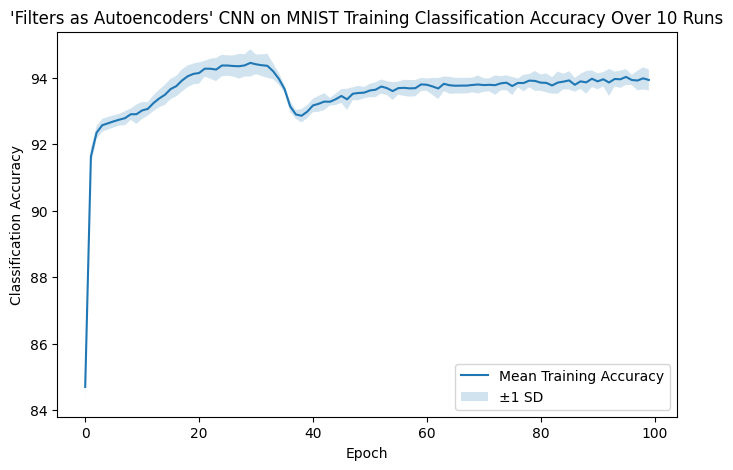

In [9]:
epochs = np.arange(len(mean_acc))

plt.figure(figsize=(8,5))

plt.plot(epochs, mean_acc,label="Mean Training Accuracy")

plt.fill_between(
    epochs,
    mean_acc - std_acc,
    mean_acc + std_acc,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' CNN on MNIST Training Classification Accuracy Over 10 Runs")
plt.show()

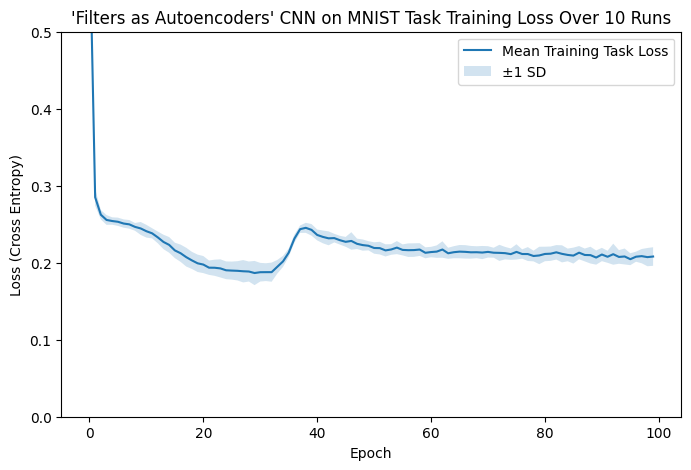

In [10]:
epochs = np.arange(len(task_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, task_mean_loss,label="Mean Training Task Loss")

plt.fill_between(
    epochs,
    task_mean_loss - task_std_loss,
    task_mean_loss + task_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("'Filters as Autoencoders' CNN on MNIST Task Training Loss Over 10 Runs")
plt.show()

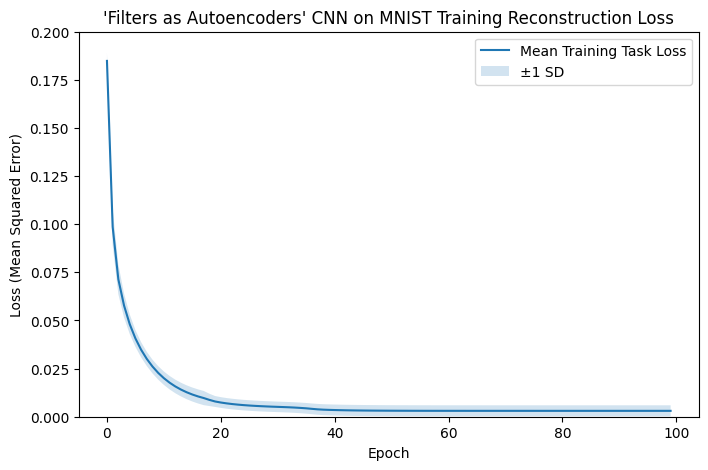

In [11]:
epochs = np.arange(len(encoder_mean_loss))

plt.figure(figsize=(8,5))

plt.plot(epochs, encoder_mean_loss,label="Mean Training Task Loss")

plt.fill_between(
    epochs,
    encoder_mean_loss - encoder_std_loss,
    encoder_mean_loss + encoder_std_loss,
    alpha=0.2,
    label="±1 SD"
)

plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(0,0.2)
plt.title("'Filters as Autoencoders' CNN on MNIST Training Reconstruction Loss")
plt.show()

# Small batch size:

In [8]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(11): #10 runs with 1 warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100

    model, training_history, elapsed = parallel_nan_cnn_experiments.train_parallel_nan_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=n_epochs,      
        batch_size=16,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        seed=seed 
    )
    

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Training Loss: 0.0475
Epoch [1/1], Task Training Loss: 0.4479, Accuracy: 88.0900%
peak memory from train : 107.73095703125
memory now reset and is: 57.96630859375 MB
time elapsed: 25.140541121999377
model run: 1
device is: cuda
Epoch [1/100], Encoder Training Loss: 0.0482
Epoch [1/100], Task Training Loss: 0.4921, Accuracy: 88.0917%
Epoch [2/100], Encoder Training Loss: 0.0098
Epoch [2/100], Task Training Loss: 0.4774, Accuracy: 89.7350%
Epoch [3/100], Encoder Training Loss: 0.0072
Epoch [3/100], Task Training Loss: 0.5314, Accuracy: 89.4083%
Epoch [4/100], Encoder Training Loss: 0.0066
Epoch [4/100], Task Training Loss: 0.5616, Accuracy: 89.4117%
Epoch [5/100], Encoder Training Loss: 0.0066
Epoch [5/100], Task Training Loss: 0.5460, Accuracy: 90.0450%
Epoch [6/100], Encoder Training Loss: 0.0066
Epoch [6/100], Task Training Loss: 0.5493, Accuracy: 90.2317%
Epoch [7/100], Encoder Training Loss: 0.0066
Epoch [7/100], Task Training Loss: 

KeyboardInterrupt: 

In [15]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(11): #10 runs with 1 warm up
    #run training and evaluation

    print(f"model run: {seed}")

    if seed == 0:
        n_epochs =1 #warm up run to avoid measuring the initial one-time allocations

    else: 
        n_epochs = 100

    model, training_history, elapsed = parallel_nan_cnn_experiments.train_parallel_nan_cnn(
        mnist,
        input_dims=28,
        learning_rate=0.0001,
        n_epochs=n_epochs,      
        batch_size=1,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        seed=seed 
    )
    

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/1], Encoder Training Loss: 0.0273
Epoch [1/1], Task Training Loss: 0.4226, Accuracy: 88.1750%
peak memory from train : 62.6318359375
memory now reset and is: 56.29150390625 MB
time elapsed: 172.51579504100027
model run: 1
device is: cuda
Epoch [1/100], Encoder Training Loss: 0.0233
Epoch [1/100], Task Training Loss: 0.4120, Accuracy: 88.3767%


KeyboardInterrupt: 

In [ ]:
#get model
from src.models import nan_cnn

#get experiment
from src.experiments import nan_cnn_experiment